# Оценка качества работы ИИ-агента

## Что мы делаем

В этой тетрадке мы научимся **оценивать качество работы ИИ-агентов** с помощью библиотеки **AgentEvals**.

**Цели:**
1. Воссоздать нашего агента SMIRNOFF_AI с улучшенными инструментами
2. Продемонстрировать все типы траекторной оценки агентов
3. Научиться выбирать правильный метод оценки для разных задач

## Что такое траекторная оценка агентов?

**Траектория агента** - это полная последовательность действий агента: какие сообщения он получил, какие инструменты вызвал, с какими аргументами, и что ответил.

**Траекторная оценка** позволяет проверить:
- Вызывает ли агент правильные инструменты?
- Передает ли корректные аргументы?
- Следует ли нужной последовательности действий?
- Качественно ли решает задачу?

## Типы оценки в AgentEvals

### 1. Trajectory Match (детерминированная проверка)
- **Strict** - точное совпадение последовательности и аргументов
- **Unordered** - те же инструменты в любом порядке  
- **Subset** - агент не вызывает лишних инструментов
- **Superset** - агент вызывает минимум требуемые инструменты

### 2. LLM-as-Judge (качественная оценка)
- **Без референса** - LLM оценивает разумность траектории
- **С референсом** - LLM сравнивает с эталонной траекторией

## Архитектура

- **Агент:** create_agent() с InMemorySaver
- **Инструменты:** rag_search, web_search, lead_capture (улучшенный), schedule_consultation (новый)
- **Оценка:** agentevals для траекторной оценки

**Документация:**
- [AgentEvals GitHub](https://github.com/langchain-ai/agentevals)
- [LangSmith Trajectory Evals](https://docs.langchain.com/langsmith/trajectory-evals)


## 1. Setup окружения

Устанавливаем пакеты, проверяем ключи API, создаём папки для данных.


In [1]:
# Установка пакетов
%pip install -q agentevals langgraph langchain-openai langchain-chroma langchain-tavily langchain-community pypdf python-dotenv


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ragas 0.4.3 requires datasets>=4.0.0, but you have datasets 3.6.0 which is incompatible.
litellm 1.83.14 requires openai==2.24.0, but you have openai 2.36.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import logging
import json
from pathlib import Path
from typing import Optional
from dotenv import load_dotenv

# Загрузка переменных окружения
load_dotenv('.env', override=True)

# Вывод всех ключей из окружения
env_keys = [
    "OPENAI_API_KEY",
    "TAVILY_API_KEY",
    "LANGSMITH_TRACING",
    "LANGSMITH_ENDPOINT",
    "LANGSMITH_API_KEY",
    "LANGSMITH_PROJECT",
    "MODEL",
    "EMBEDDING_MODEL",
]

print("Переменные окружения:")
for key in env_keys:
    value = os.getenv(key)
    if value:
        masked_value = value[:20] + "..." if len(value) > 20 else value
        print(f"  {key}: {masked_value}")
    else:
        print(f"  {key}: не установлена")
print()

# Проверка ключевых API ключей
required_keys = ["OPENAI_API_KEY", "TAVILY_API_KEY"]
missing_keys = [key for key in required_keys if not os.getenv(key)]

if missing_keys:
    raise ValueError(f"Отсутствуют переменные окружения: {missing_keys}")

# Создание папок
Path("./var/chromadb").mkdir(parents=True, exist_ok=True)
Path("./data/pdf").mkdir(parents=True, exist_ok=True)

# Базовый логгер
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

logger.info("Setup завершён ✅")


INFO:__main__:Setup завершён ✅


Переменные окружения:
  OPENAI_API_KEY: sk-proj-nqlTYLZsVxZt...
  TAVILY_API_KEY: tvly-dev-17Ns5X-iMJh...
  LANGSMITH_TRACING: не установлена
  LANGSMITH_ENDPOINT: не установлена
  LANGSMITH_API_KEY: lsv2_pt_36b67ae67d7e...
  LANGSMITH_PROJECT: llmstart_agents_live
  MODEL: gpt-4.1
  EMBEDDING_MODEL: text-embedding-3-lar...



## 2. Данные и индекс

Загружаем PDF-файлы, разбиваем на части и создаём поисковый индекс для RAG.


In [3]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma
import glob

# Отключаем телеметрию Chroma
os.environ["ANONYMIZED_TELEMETRY"] = "False"

# Сканируем PDF файлы
pdf_files = glob.glob("./data/pdf/*.pdf")
if not pdf_files:
    raise FileNotFoundError("Нет PDF файлов в ./data/pdf/")

logger.info(f"Найдено PDF файлов: {len(pdf_files)}")
for file in pdf_files:
    logger.info(f"- {file}")


/opt/homebrew/Caskroom/miniconda/base/envs/llmstart-agents/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:datasets:PyTorch version 2.8.0 available.
INFO:__main__:Найдено PDF файлов: 1
INFO:__main__:- ./data/pdf/SMIRNOFF_AI_PORTFOLIO_LLMSTART.pdf


In [4]:
# Загрузка и нарезка PDF
all_docs = []

for pdf_file in pdf_files:
    loader = PyPDFLoader(pdf_file)
    pages = loader.load()
    logger.info(f"Загружено страниц из {pdf_file}: {len(pages)}")
    all_docs.extend(pages)

# Разбиваем на чанки
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1200, 
    chunk_overlap=150
)
doc_chunks = text_splitter.split_documents(all_docs)

logger.info(f"Создано чанков: {len(doc_chunks)}")
logger.info(f"Пример чанка: {doc_chunks[0].page_content[:200]}...")


INFO:__main__:Загружено страниц из ./data/pdf/SMIRNOFF_AI_PORTFOLIO_LLMSTART.pdf: 12
INFO:__main__:Создано чанков: 15
INFO:__main__:Пример чанка: ИИ-АССИСТЕНТ
 
СОТРУДНИКА
 
МЕДИА-АГЕНТСТВА
  Заказчик  MediaWise   Проблематика,  задача  -  Накоплена  огромная  база  материалов  (рабочих,  образовательных  и  
организационных).
 
Сотрудники
 
аг...


In [5]:
# Создание Chroma индекса
import chromadb

embeddings = OpenAIEmbeddings(model=os.getenv("EMBEDDING_MODEL"))
chroma_path = "./var/chromadb"

# Удаляем существующую коллекцию для воспроизводимости
client = chromadb.PersistentClient(path=chroma_path)
try:
    client.delete_collection("smirnoff_ai_docs")
    logger.info("Старая коллекция удалена")
except:
    logger.info("Коллекция не существует")

# Создаем векторное хранилище
vectorstore = Chroma.from_documents(
    documents=doc_chunks,
    collection_name="smirnoff_ai_docs",
    embedding=embeddings,
    persist_directory=chroma_path,
)

logger.info(f"Chroma индекс создан ✅")
logger.info(f"Коллекция: smirnoff_ai_docs")
logger.info(f"Документов в индексе: {vectorstore._collection.count()}")


INFO:__main__:Коллекция не существует
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:__main__:Chroma индекс создан ✅
INFO:__main__:Коллекция: smirnoff_ai_docs
INFO:__main__:Документов в индексе: 15


## 3. Инициализация провайдеров

Настройка OpenAI, Chroma retriever и Tavily для веб-поиска.


In [6]:
from langchain_openai import ChatOpenAI
from langchain_tavily import TavilySearch

# Модель для диалога  
llm = ChatOpenAI(
    model=os.getenv("MODEL"),
    temperature=0.7,
    max_tokens=700
)

# Chroma retriever
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3}
)

# Tavily для веб-поиска
tavily_search = TavilySearch(max_results=3)

logger.info("OpenAI LLM настроен ✅")
logger.info("Chroma retriever настроен ✅")
logger.info("Tavily клиент настроен ✅")


INFO:__main__:OpenAI LLM настроен ✅
INFO:__main__:Chroma retriever настроен ✅
INFO:__main__:Tavily клиент настроен ✅


## 4. Инструменты агента с улучшенной структурой

Создаём 4 инструмента:
- `rag_search` - поиск в документах
- `web_search` - веб-поиск
- `lead_capture` - **улучшенный** со структурированными параметрами
- `schedule_consultation` - **новый** для записи на консультацию


In [7]:
from langchain_core.tools import tool

@tool
def rag_search(query: str) -> str:
    """Ищет информацию о кейсах и программах обучения SMIRNOFF_AI в загруженных PDF документах."""
    docs = retriever.invoke(query)
    
    if not docs:
        return "По данному запросу информация в наших материалах не найдена."
    
    # Собираем контекст без указания источников
    context_parts = []
    for doc in docs:
        content = doc.page_content.strip()
        if content:
            context_parts.append(content)
    
    combined_context = "\n\n".join(context_parts)
    return combined_context

logger.info("RAG инструмент создан ✅")


INFO:__main__:RAG инструмент создан ✅


In [8]:
@tool
def web_search(query: str) -> str:
    """Выполняет веб-поиск для вопросов вне домена услуг и кейсов компании SMIRNOFF_AI."""
    try:
        results = tavily_search.invoke({"query": query})
        
        if not results:
            return "По данному запросу информация в интернете не найдена."
        
        # TavilySearch возвращает строку
        if isinstance(results, str):
            return results[:500] + "..." if len(results) > 500 else results
        
        # Если это список (для совместимости)
        elif isinstance(results, list) and len(results) > 0:
            summaries = []
            for result in results[:2]:
                if isinstance(result, dict) and 'content' in result:
                    content = result['content'][:300]
                    summaries.append(content)
                elif isinstance(result, str):
                    summaries.append(result[:300])
            return "\n\n".join(summaries) if summaries else "Не удалось получить релевантную информацию."
        
        # Если это другой тип объекта
        else:
            result_str = str(results)
            return result_str[:500] + "..." if len(result_str) > 500 else result_str
        
    except Exception as e:
        logger.error(f"Ошибка web_search: {type(e).__name__}: {str(e)}")
        return f"Ошибка при поиске. Попробуйте переформулировать вопрос."

logger.info("Веб-поиск инструмент создан ✅")


INFO:__main__:Веб-поиск инструмент создан ✅


In [9]:
@tool
def lead_capture(
    full_name: str,
    email: Optional[str] = None,
    phone: Optional[str] = None,
    company: Optional[str] = None,
    request_description: str = ""
) -> str:
    """Сохраняет структурированную контактную информацию потенциального клиента.
    
    Args:
        full_name: Полное имя клиента
        email: Email клиента (опционально)
        phone: Телефон клиента (опционально)
        company: Название компании (опционально)
        request_description: Описание запроса/проекта
    """
    # Формируем строку с контактной информацией
    contact_info = f"Имя: {full_name}"
    if email:
        contact_info += f", Email: {email}"
    if phone:
        contact_info += f", Телефон: {phone}"
    if company:
        contact_info += f", Компания: {company}"
    if request_description:
        contact_info += f", Запрос: {request_description}"
    
    # Логируем сохраненную информацию
    logger.info(f"💼 Лид сохранен: {contact_info}")
    
    return f"Контактная информация сохранена. Наш менеджер свяжется с вами в ближайшее время. {contact_info[:100]}"

logger.info("Улучшенный инструмент сбора лидов создан ✅")


INFO:__main__:Улучшенный инструмент сбора лидов создан ✅


In [10]:
@tool
def schedule_consultation(
    client_name: str,
    email: str,
    preferred_date: str,
    preferred_time: str,
    topic: str
) -> str:
    """Записывает клиента на консультацию с указанием даты, времени и темы.
    
    Args:
        client_name: Имя клиента
        email: Email для подтверждения
        preferred_date: Предпочтительная дата (YYYY-MM-DD или текстовое описание)
        preferred_time: Предпочтительное время ("morning"/"утро", "afternoon"/"день", "evening"/"вечер")
        topic: Тема консультации
    """
    # Формируем информацию о записи
    consultation_info = (
        f"Клиент: {client_name}, "
        f"Email: {email}, "
        f"Дата: {preferred_date}, "
        f"Время: {preferred_time}, "
        f"Тема: {topic}"
    )
    
    # Логируем запись
    logger.info(f"📅 Консультация запланирована: {consultation_info}")
    
    return (
        f"Консультация успешно запланирована!\n"
        f"Дата: {preferred_date}\n"
        f"Время: {preferred_time}\n"
        f"Тема: {topic}\n"
        f"Подтверждение отправлено на {email}"
    )

logger.info("Новый инструмент планирования консультаций создан ✅")


INFO:__main__:Новый инструмент планирования консультаций создан ✅


## 5. Создание агента с create_agent()

Используем упрощенный подход с `create_agent()` и `InMemorySaver`.


In [11]:
# Загрузка информации о компании для системного промпта
with open("./data/prompt_info.txt", "r", encoding="utf-8") as f:
    company_info = f.read()

logger.info("Информация о компании загружена ✅")


INFO:__main__:Информация о компании загружена ✅


In [12]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import MemorySaver

# Создаем список инструментов
tools = [rag_search, web_search, lead_capture, schedule_consultation]

# Создаем checkpointer с InMemorySaver
checkpointer = MemorySaver()

# Создаем агента
agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt=f"""Ты - ИИ-консультант AI-агентства SMIRNOFF_AI.

{company_info}

ПРАВИЛА ОТВЕТОВ:
- Всегда отвечай на русском языке
- Будь кратким и деловым (3-5 предложений)  
- Не указывай источники при использовании RAG
- Ссылки в веб-поиске - только при явном запросе
- После каждого ответа предлагай следующий шаг (CTA)

ИНСТРУМЕНТЫ:
- rag_search: для поиска в наших кейсах и программах обучения
- web_search: обязательно использовать для веб-поиска по всем вопросам вне кейсов и программ
- lead_capture: для сохранения контактов клиентов (используй структурированные параметры)
- schedule_consultation: для записи клиентов на консультацию

Помогай клиентам найти подходящие AI-решения для их бизнеса.""",
    checkpointer=checkpointer
)

logger.info("Агент создан с create_agent() и InMemorySaver ✅")
logger.info(f"Всего инструментов: {len(tools)}")


INFO:__main__:Агент создан с create_agent() и InMemorySaver ✅
INFO:__main__:Всего инструментов: 4


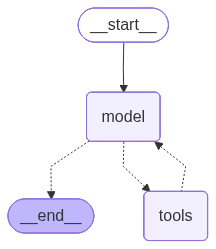

INFO:__main__:Граф агента визуализирован ✅


In [13]:
# Визуализация графа агента
from IPython.display import Image, display

try:
    graph_image = agent.get_graph().draw_mermaid_png()
    display(Image(graph_image))
    logger.info("Граф агента визуализирован ✅")
except Exception as e:
    logger.warning(f"Не удалось создать PNG: {e}")
    print("\n📊 Структура графа агента:\n")
    print(agent.get_graph().draw_mermaid())


## 6. Демонстрация работы агента

Проверяем что агент корректно работает со всеми инструментами.


In [14]:
# Helper функция для тестирования
def run_agent(chat_id: str, user_message: str):
    """Запускает агента и выводит результат."""
    config = {"configurable": {"thread_id": chat_id}}
    inputs = {"messages": [{"role": "user", "content": user_message}]}
    
    print(f"\n💬 Пользователь: {user_message}")
    print("=" * 60)
    
    for step in agent.stream(inputs, config=config, stream_mode="values"):
        step["messages"][-1].pretty_print()
    
    print("=" * 60)
    return config

logger.info("Helper функция создана ✅")


INFO:__main__:Helper функция создана ✅


In [15]:
# Тест 1: RAG search
print("\n🧪 ТЕСТ 1: Поиск в документах (rag_search)")
run_agent("demo_1", "Какие кейсы для медиа-агентств у вас есть?")



🧪 ТЕСТ 1: Поиск в документах (rag_search)

💬 Пользователь: Какие кейсы для медиа-агентств у вас есть?
================================ Human Message =================================

Какие кейсы для медиа-агентств у вас есть?


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


================================== Ai Message ==================================
Tool Calls:
  rag_search (call_FDNTBM0sIMgCMPIWzAtWSWjx)
 Call ID: call_FDNTBM0sIMgCMPIWzAtWSWjx
  Args:
    query: кейсы для медиа-агентств


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


================================= Tool Message =================================
Name: rag_search

ИИ-АССИСТЕНТ
 
СОТРУДНИКА
 
МЕДИА-АГЕНТСТВА
  Заказчик  MediaWise   Проблематика,  задача  -  Накоплена  огромная  база  материалов  (рабочих,  образовательных  и  
организационных).
 
Сотрудники
 
агентства
 
не
 
используют
 
накопленные
 
знания,
 
изобретают
 
решения
 
заново,
 
что
 
снижает
 
эффективность
 
работы.
 
 Решение  -  видео  демонстрация  https://tinyurl.com/bde9x3up База  знаний  содержит  огромное  количество  маркетинговых  материалов,  в  которых  
основная
 
информация
 
содержится
 
в
 
визуальных
 
элементах
 
(таблицы,
 
графики,
 
инфографика).

ИИ-АССИСТЕНТ
 
РЕДАКТОРА
 
PITER.TV
  Заказчик  piter.tv   Проблематика,  задача  -  Повысить  эффективность  работы  редакции  сетевого  издания  при  подготовке  к  
публикации
 
новостных
 
материалов
 
за
 
счет
 
автоматизации
 
процесса
 
сбора
 
дополнительной
 
фактологической
 
и
 
визуальной
 
информации
 
по

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


================================== Ai Message ==================================

У нас есть реализованные кейсы для медиа-агентств: ИИ-ассистент сотрудника (MediaWise) — автоматизация поиска и использования накопленных знаний и материалов, включая визуальные элементы. ИИ-ассистент редактора (piter.tv) — автоматизация сбора информации, генерация альтернативных версий новостей и изображений, ускорение подготовки материалов в 6 раз. Оба решения повышают эффективность работы и экономят время сотрудников.

Готов прислать подробности по каждому кейсу или обсудить задачи вашего агентства — что интереснее?


{'configurable': {'thread_id': 'demo_1'}}

In [16]:
# Тест 2: Lead capture с структурированными параметрами
print("\n🧪 ТЕСТ 2: Сбор лида (lead_capture)")
run_agent("demo_1", "Меня зовут Иван Петров, моя почта ivan@company.ru, компания TechCorp, хочу автоматизировать поддержку")



🧪 ТЕСТ 2: Сбор лида (lead_capture)

💬 Пользователь: Меня зовут Иван Петров, моя почта ivan@company.ru, компания TechCorp, хочу автоматизировать поддержку
================================ Human Message =================================

Меня зовут Иван Петров, моя почта ivan@company.ru, компания TechCorp, хочу автоматизировать поддержку


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:💼 Лид сохранен: Имя: Иван Петров, Email: ivan@company.ru, Компания: TechCorp, Запрос: Автоматизация поддержки для медиа-агентства


================================== Ai Message ==================================
Tool Calls:
  lead_capture (call_3FFkRXQwYyB2uWnxYiD9t9Wd)
 Call ID: call_3FFkRXQwYyB2uWnxYiD9t9Wd
  Args:
    full_name: Иван Петров
    email: ivan@company.ru
    company: TechCorp
    request_description: Автоматизация поддержки для медиа-агентства
================================= Tool Message =================================
Name: lead_capture

Контактная информация сохранена. Наш менеджер свяжется с вами в ближайшее время. Имя: Иван Петров, Email: ivan@company.ru, Компания: TechCorp, Запрос: Автоматизация поддержки для ме


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


================================== Ai Message ==================================

Иван, благодарю за информацию! Мы сохранили ваши контакты и запрос. В ближайшее время наш специалист свяжется с вами для уточнения деталей и подбора оптимального AI-решения для автоматизации поддержки.

Хотите сразу записаться на консультацию по удобному времени?


{'configurable': {'thread_id': 'demo_1'}}

In [17]:
# Тест 3: Schedule consultation
print("\n🧪 ТЕСТ 3: Запись на консультацию (schedule_consultation)")
run_agent("demo_3", "Записи меня на консультацию по внедрению AI. Имя Мария Иванова, email maria@startup.io, предпочитаю завтра утром")



🧪 ТЕСТ 3: Запись на консультацию (schedule_consultation)

💬 Пользователь: Записи меня на консультацию по внедрению AI. Имя Мария Иванова, email maria@startup.io, предпочитаю завтра утром
================================ Human Message =================================

Записи меня на консультацию по внедрению AI. Имя Мария Иванова, email maria@startup.io, предпочитаю завтра утром


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:📅 Консультация запланирована: Клиент: Мария Иванова, Email: maria@startup.io, Дата: 2024-06-13, Время: утро, Тема: Внедрение AI


================================== Ai Message ==================================
Tool Calls:
  schedule_consultation (call_GiSmN9wajiJ18N5gWRoc0GtK)
 Call ID: call_GiSmN9wajiJ18N5gWRoc0GtK
  Args:
    client_name: Мария Иванова
    email: maria@startup.io
    preferred_date: 2024-06-13
    preferred_time: утро
    topic: Внедрение AI
================================= Tool Message =================================
Name: schedule_consultation

Консультация успешно запланирована!
Дата: 2024-06-13
Время: утро
Тема: Внедрение AI
Подтверждение отправлено на maria@startup.io


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


================================== Ai Message ==================================

Вы успешно записаны на консультацию по внедрению AI на завтра утром. Подтверждение отправлено на вашу почту maria@startup.io. 

Если нужно подготовить вопросы или кейсы для обсуждения — дайте знать!


{'configurable': {'thread_id': 'demo_3'}}

---

# Часть 2: Траекторная оценка агентов

Теперь переходим к оценке качества работы агента с помощью **AgentEvals**.


## 7. Подготовка к оценке

### Что такое траектория?

**Траектория (trajectory)** - это последовательность сообщений в диалоге:
- Сообщения пользователя (`HumanMessage`)
- Ответы агента (`AIMessage`)
- Вызовы инструментов (`tool_calls` внутри `AIMessage`)
- Результаты инструментов (`ToolMessage`)

### Формат для agentevals

AgentEvals работает с **списком сообщений LangChain** (`BaseMessage`). Нам нужно извлекать траектории из запусков агента.


In [18]:
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage

def extract_trajectory(chat_id: str, user_message: str):
    """Запускает агента и извлекает траекторию сообщений."""
    config = {"configurable": {"thread_id": chat_id}}
    inputs = {"messages": [{"role": "user", "content": user_message}]}
    
    # Запускаем агента
    result = agent.invoke(inputs, config=config)
    
    # Извлекаем траекторию (список сообщений)
    trajectory = result["messages"]
    
    return trajectory

def print_trajectory(trajectory):
    """Выводит траекторию ПОЛНОСТЬЮ - все поля для понимания структуры."""
    print(f"\n📋 Траектория ({len(trajectory)} сообщений):")
    print("=" * 100)
    
    for i, msg in enumerate(trajectory):
        msg_type = type(msg).__name__
        
        # HumanMessage
        if msg_type == "HumanMessage":
            print(f"\n[{i+1}] HumanMessage")
            print(f"     content={repr(msg.content)}")
        
        # AIMessage с tool_calls
        elif msg_type == "AIMessage" and hasattr(msg, 'tool_calls') and msg.tool_calls:
            print(f"\n[{i+1}] AIMessage (tool_calls)")
            print(f"     content={repr(msg.content)}")
            print(f"     tool_calls=[")
            for j, tc in enumerate(msg.tool_calls):
                print(f"       {{")
                print(f"         'id': {repr(tc.get('id', 'N/A'))},")
                print(f"         'name': {repr(tc['name'])},")
                print(f"         'args': {json.dumps(tc['args'], ensure_ascii=False)}")
                print(f"       }}" + ("," if j < len(msg.tool_calls) - 1 else ""))
            print(f"     ]")
        
        # AIMessage с ответом
        elif msg_type == "AIMessage":
            print(f"\n[{i+1}] AIMessage (response)")
            content_preview = msg.content[:200] + "..." if len(msg.content) > 200 else msg.content
            print(f"     content={repr(content_preview)}")
        
        # ToolMessage
        elif msg_type == "ToolMessage":
            print(f"\n[{i+1}] ToolMessage")
            print(f"     name={repr(msg.name)}")
            print(f"     tool_call_id={repr(msg.tool_call_id)}")
            content_preview = msg.content[:150] + "..." if len(msg.content) > 150 else msg.content
            print(f"     content={repr(content_preview)}")
        
        # Другие типы
        else:
            print(f"\n[{i+1}] {msg_type}")
            if hasattr(msg, 'content') and msg.content:
                content_preview = msg.content[:150] + "..." if len(msg.content) > 150 else msg.content
                print(f"     content={repr(content_preview)}")
    
    print("=" * 100)

logger.info("Helper функции для работы с траекториями созданы ✅")


INFO:__main__:Helper функции для работы с траекториями созданы ✅


In [19]:
# Пример извлечения траектории
test_trajectory = extract_trajectory("trajectory_test", "Какие кейсы у вас есть?")
print_trajectory(test_trajectory)


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



📋 Траектория (4 сообщений):

[1] HumanMessage
     content='Какие кейсы у вас есть?'

[2] AIMessage (tool_calls)
     content=''
     tool_calls=[
       {
         'id': 'call_JDVG2SSNT9Fl0D0lQ8pa0fA5',
         'name': 'rag_search',
         'args': {"query": "кейсы"}
       }
     ]

[3] ToolMessage
     name='rag_search'
     tool_call_id='call_JDVG2SSNT9Fl0D0lQ8pa0fA5'
     content='ИИ-АССИСТЕНТ\n \nСОТРУДНИКА\n \nМЕДИА-АГЕНТСТВА\n  Заказчик  MediaWise   Проблематика,  задача  -  Накоплена  огромная  база  материалов  (рабочих,  образо...'

[4] AIMessage (response)
     content='Вот несколько наших кейсов:\n\n1. ИИ-ассистент для сотрудников медиа-агентства: автоматизация поиска знаний в большой базе маркетинговых материалов, включая работу с визуальным контентом (таблицы, графи...'


## 8. Trajectory Match - Strict Mode

### Что такое Strict Mode?

**Strict** mode проверяет **точное совпадение** траектории:
- Одинаковое количество сообщений
- Одинаковая последовательность
- Одинаковые инструменты с одинаковыми аргументами

**Когда использовать:**
- Когда есть четкая последовательность действий
- Для регрессионного тестирования (агент должен делать ровно то же самое)
- Когда важна точность аргументов инструментов

**Ограничения:**
- Очень строгий - даже небольшие отклонения приведут к провалу
- Не подходит для сценариев с вариативностью


In [20]:
from agentevals.trajectory.match import create_trajectory_match_evaluator

# Создаем evaluator для strict mode
strict_evaluator = create_trajectory_match_evaluator(
    trajectory_match_mode="strict",
    tool_args_match_mode="ignore"
)

logger.info("Strict evaluator создан ✅")


INFO:__main__:Strict evaluator создан ✅


### Пример 1: Strict проверка с lead_capture

Проверяем что агент корректно извлекает и сохраняет контактную информацию.

**Ожидание:** Агент должен вызвать `lead_capture` с точными параметрами: `full_name="Иван Петров"`, `email="ivan@test.ru"`, `request_description="автоматизация"`.

**Реальность:** Даже с тем же запросом strict mode скорее всего **провалится** из-за:
- Разные `tool_call id` (генерируются случайно)
- Разные финальные ответы AIMessage (LLM недетерминирована)


In [21]:
# ===== РЕФЕРЕНСНАЯ ТРАЕКТОРИЯ (создаем ВРУЧНУЮ) =====
print("📘 РЕФЕРЕНСНАЯ ТРАЕКТОРИЯ (эталон):")
print("Создаем вручную - показываем ожидаемое поведение агента")
print("Используем lead_capture - детерминированный инструмент с фиксированным результатом\n")

reference_strict = [
    HumanMessage(content="Меня зовут Иван Петров, email ivan@test.ru, хочу автоматизацию. Сохраните меня в базу"),
    
    AIMessage(
        content="",
        tool_calls=[{
            "id": "call_ref_1",
            "name": "lead_capture",
            "args": {
                "full_name": "Иван Петров",
                "email": "ivan@test.ru",
                "phone": None,
                "company": None,
                "request_description": "автоматизация"
            }
        }]
    ),
    
    ToolMessage(
        content="Контактная информация сохранена. Наш менеджер свяжется с вами в ближайшее время. Имя: Иван Петров, Email: ivan@test.ru, Запрос: автоматизация",
        tool_call_id="call_ref_1",
        name="lead_capture"
    ),
    
    AIMessage(content="Спасибо, Иван! Ваша заявка принята. Наш менеджер свяжется с вами в ближайшее время.")
]

print_trajectory(reference_strict)

# ===== ФАКТИЧЕСКАЯ ТРАЕКТОРИЯ (запускаем агента с ТЕМ ЖЕ запросом) =====
print("\n\n✅ ФАКТИЧЕСКАЯ ТРАЕКТОРИЯ (тот же запрос):")
actual_strict_same = extract_trajectory("strict_same_03", "Меня зовут Иван Петров, email ivan@test.ru, хочу автоматизацию. Сохраните меня в базу")
print_trajectory(actual_strict_same)

# ===== ОЦЕНКА: вероятно НЕ совпадет из-за недетерминированности LLM =====
result_same = strict_evaluator(
    outputs=actual_strict_same,
    reference_outputs=reference_strict
)

print(f"\n📊 Результат оценки (тот же запрос):")
print(f"   Ключ: {result_same['key']}")
print(f"   Совпадение: {result_same['score']}")
print(f"   Комментарий: {result_same.get('comment', 'Нет')}")

if result_same['score']:
    print("\n✅ Траектории совпали!")
    print("   🎯 Агент вызвал lead_capture с точно теми же аргументами")
    print("   🎯 ToolMessage content совпал (детерминированный)")
    print("   🎯 AIMessage response случайно совпал (редкость!)")
else:
    print("\n❌ Не совпало, даже с тем же запросом!")
    print("💡 Вероятные причины:")
    print("   - Финальный AIMessage response отличается (LLM недетерминирована)")
    print("   - Tool_call id отличается (генерируется случайно)")
    print("   - Агент извлек данные немного по-другому")
    print("\n⚠️ Strict mode ОЧЕНЬ строгий - даже мелкие вариации провалят тест!")


📘 РЕФЕРЕНСНАЯ ТРАЕКТОРИЯ (эталон):
Создаем вручную - показываем ожидаемое поведение агента
Используем lead_capture - детерминированный инструмент с фиксированным результатом


📋 Траектория (4 сообщений):

[1] HumanMessage
     content='Меня зовут Иван Петров, email ivan@test.ru, хочу автоматизацию. Сохраните меня в базу'

[2] AIMessage (tool_calls)
     content=''
     tool_calls=[
       {
         'id': 'call_ref_1',
         'name': 'lead_capture',
         'args': {"full_name": "Иван Петров", "email": "ivan@test.ru", "phone": null, "company": null, "request_description": "автоматизация"}
       }
     ]

[3] ToolMessage
     name='lead_capture'
     tool_call_id='call_ref_1'
     content='Контактная информация сохранена. Наш менеджер свяжется с вами в ближайшее время. Имя: Иван Петров, Email: ivan@test.ru, Запрос: автоматизация'

[4] AIMessage (response)
     content='Спасибо, Иван! Ваша заявка принята. Наш менеджер свяжется с вами в ближайшее время.'


✅ ФАКТИЧЕСКАЯ ТРАЕКТОРИЯ (то

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:💼 Лид сохранен: Имя: Иван Петров, Email: ivan@test.ru, Запрос: Хочу автоматизацию
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



📋 Траектория (4 сообщений):

[1] HumanMessage
     content='Меня зовут Иван Петров, email ivan@test.ru, хочу автоматизацию. Сохраните меня в базу'

[2] AIMessage (tool_calls)
     content=''
     tool_calls=[
       {
         'id': 'call_XBVyjHWwXpXpoSP0KqJFYGpU',
         'name': 'lead_capture',
         'args': {"full_name": "Иван Петров", "email": "ivan@test.ru", "request_description": "Хочу автоматизацию"}
       }
     ]

[3] ToolMessage
     name='lead_capture'
     tool_call_id='call_XBVyjHWwXpXpoSP0KqJFYGpU'
     content='Контактная информация сохранена. Наш менеджер свяжется с вами в ближайшее время. Имя: Иван Петров, Email: ivan@test.ru, Запрос: Хочу автоматизацию'

[4] AIMessage (response)
     content='Ваша заявка успешно сохранена, Иван. Наш специалист свяжется с вами для уточнения деталей автоматизации вашего бизнеса.\n\nХотите сразу записаться на консультацию или предпочитаете дождаться звонка мене...'

📊 Результат оценки (тот же запрос):
   Ключ: trajectory_strict_mat

### Пример 2: Несовпадение из-за разных аргументов

Агент вызывает инструмент, но с другими аргументами.


In [22]:
# ===== ФАКТИЧЕСКАЯ ТРАЕКТОРИЯ #2 (другие данные клиента) =====
print("\n\n❌ ФАКТИЧЕСКАЯ ТРАЕКТОРИЯ (другие данные):")
actual_strict_diff = extract_trajectory("strict_diff", "Я Мария Сидорова, maria@company.ru, нужна консультация")
print_trajectory(actual_strict_diff)

# ===== ОЦЕНКА: точно НЕ совпадет (другие аргументы) =====
result_diff = strict_evaluator(
    outputs=actual_strict_diff,
    reference_outputs=reference_strict
)

print(f"\n📊 Результат оценки (другие данные):")
print(f"   Ключ: {result_diff['key']}")
print(f"   Совпадение: {result_diff['score']}")
print(f"   Комментарий: {result_diff.get('comment', 'Нет')}")

if not result_diff['score']:
    print("\n❌ Ожидаемо не совпало!")
    print("💡 Причины:")
    print("   - Разный user query в HumanMessage")
    print("   - Разные аргументы в lead_capture:")
    print("     • full_name: 'Иван Петров' ≠ 'Мария Сидорова'")
    print("     • email: 'ivan@test.ru' ≠ 'maria@company.ru'")
    print("     • request_description: 'автоматизация' ≠ 'консультация'")
    print("\n⚠️ Strict mode требует ТОЧНОГО совпадения всех полей!")
else:
    print("\n✅ Неожиданно совпало (не должно было!)")




❌ ФАКТИЧЕСКАЯ ТРАЕКТОРИЯ (другие данные):


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



📋 Траектория (2 сообщений):

[1] HumanMessage
     content='Я Мария Сидорова, maria@company.ru, нужна консультация'

[2] AIMessage (response)
     content='Мария, благодарю за обращение! Уточните, пожалуйста, по какой теме или проекту вам нужна консультация, а также желаемую дату и время (утро, день, вечер). Это поможет подобрать для вас оптимального экс...'

📊 Результат оценки (другие данные):
   Ключ: trajectory_strict_match
   Совпадение: False
   Комментарий: None

❌ Ожидаемо не совпало!
💡 Причины:
   - Разный user query в HumanMessage
   - Разные аргументы в lead_capture:
     • full_name: 'Иван Петров' ≠ 'Мария Сидорова'
     • email: 'ivan@test.ru' ≠ 'maria@company.ru'
     • request_description: 'автоматизация' ≠ 'консультация'

⚠️ Strict mode требует ТОЧНОГО совпадения всех полей!


## 9. Trajectory Match - Unordered Mode

### Что такое Unordered Mode?

**Unordered** mode проверяет что агент вызывает **те же инструменты**, но **порядок не важен**.

**Отличия от Strict:**
- ✅ Strict требует ТОЧНУЮ последовательность вызовов
- ✅ Unordered проверяет только ЧТО вызвано, не КОГДА

**Когда использовать:**
- Порядок выполнения инструментов не критичен
- Для параллельных или независимых операций  
- Агент может получать информацию в любой последовательности

**Пример:** Клиент спрашивает о кейсах И записывается на консультацию - порядок этих действий неважен.

### Настройка проверки аргументов: `tool_args_match_mode`

По умолчанию Unordered **проверяет аргументы** инструментов. Но можно настроить:

```python
tool_args_match_mode = "exact"    # По умолчанию - точное совпадение аргументов
tool_args_match_mode = "ignore"   # Не проверять аргументы совсем!
tool_args_match_mode = "subset"   # Агент использует подмножество аргументов
tool_args_match_mode = "superset" # Агент использует минимум эти аргументы + возможно больше
```

**В нашем примере:** используем `"ignore"` - проверяем только ФАКТ вызова инструментов, не их аргументы!


In [23]:
# Создаем evaluator для unordered mode + НЕ проверяем аргументы!
unordered_evaluator = create_trajectory_match_evaluator(
    trajectory_match_mode="unordered",
    tool_args_match_mode="ignore"  # ← Проверяем только ФАКТ вызова инструментов, а не их аргументы!
)

logger.info("Unordered evaluator создан ✅ (аргументы игнорируются)")


INFO:__main__:Unordered evaluator создан ✅ (аргументы игнорируются)


### Пример: Агент вызывает инструменты в любом порядке

Клиент спрашивает о кейсах И записывается на консультацию.

**Референс:** сначала `rag_search`, потом `schedule_consultation`  
**Фактический:** агент может вызвать в обратном порядке

**Важно:** Используем `tool_args_match_mode="ignore"` - проверяем только **ФАКТ вызова** инструментов, не их аргументы!

**Unordered mode должен пройти** ✅ - порядок не важен!


In [24]:
# ===== РЕФЕРЕНСНАЯ ТРАЕКТОРИЯ (создаем ВРУЧНУЮ) =====
print("📘 РЕФЕРЕНСНАЯ ТРАЕКТОРИЯ (эталон):")
print("Агент СНАЧАЛА ищет в RAG, ПОТОМ записывает на консультацию")
print("⚠️ Аргументы НЕ важны - проверяем только ФАКТ вызова инструментов!\n")

reference_unordered = [
    HumanMessage(content="Расскажи о кейсах для агро и запиши меня на консультацию. Иван, ivan@test.ru, завтра утром"),
    
    # ПЕРВЫЙ вызов - rag_search (порядок в референсе)
    AIMessage(
        content="",
        tool_calls=[{
            "id": "call_ref_1",
            "name": "rag_search",
            "args": {"query": "кейсы агро"}  # Аргументы НЕ важны!
        }]
    ),
    
    ToolMessage(
        content="Найдены кейсы...",
        tool_call_id="call_ref_1",
        name="rag_search"
    ),
    
    # ВТОРОЙ вызов - schedule_consultation (порядок в референсе)
    AIMessage(
        content="",
        tool_calls=[{
            "id": "call_ref_2",
            "name": "schedule_consultation",
            "args": {
                "client_name": "Иван",
                "email": "ivan@test.ru",
                "preferred_date": "завтра",
                "preferred_time": "утром",
                "topic": "агро"
            }  # Аргументы НЕ важны!
        }]
    ),
    
    ToolMessage(
        content="Консультация запланирована...",
        tool_call_id="call_ref_2",
        name="schedule_consultation"
    ),
    
    AIMessage(content="Ответ агента...")
]

print_trajectory(reference_unordered)

# ===== ФАКТИЧЕСКАЯ ТРАЕКТОРИЯ (запускаем агента) =====
print("\n\n📗 ФАКТИЧЕСКАЯ ТРАЕКТОРИЯ:")
print("Агент может вызвать те же инструменты в ДРУГОМ порядке\n")
actual_unordered = extract_trajectory("unordered_test_05", "Запиши меня на консультацию. Иван, ivan@test.ru, завтра утром и расскажи о кейсах для агро")
print_trajectory(actual_unordered)

# ===== ОЦЕНКА: должен пройти! =====
result_unordered = unordered_evaluator(
    outputs=actual_unordered,
    reference_outputs=reference_unordered
)

print(f"\n📊 Результат оценки (Unordered):")
print(f"   Ключ: {result_unordered['key']}")
print(f"   Совпадение: {result_unordered['score']}")
print(f"   Комментарий: {result_unordered.get('comment', 'Нет')}")

if result_unordered['score']:
    print("\n✅ Траектории совпали!")
    print("💡 Unordered mode успешно проверил:")
    print("   ✅ Агент вызвал те же 2 инструмента (rag_search + schedule_consultation)")
    print("   ✅ Порядок вызовов НЕ важен!")
    print("   ✅ Аргументы проигнорированы (tool_args_match_mode='ignore')")
    print("\n🎯 Отличная новость - unordered mode идеален для проверки что агент")
    print("   выполнил нужный набор действий, независимо от порядка!")
else:
    print("\n❌ Не совпало!")
    print("💡 Возможные причины:")
    print("   - Агент вызвал ДРУГИЕ инструменты (не rag_search или не schedule_consultation)")
    print("   - Или вызвал ДРУГОЕ КОЛИЧЕСТВО инструментов (не 2)")
    print("   - Или вызвал только один инструмент вместо двух")
    print("\n⚠️ Unordered проверяет ЧТО и СКОЛЬКО РАЗ вызвано, но НЕ проверяет КОГДА и С КАКИМИ АРГУМЕНТАМИ (если ignore)")


📘 РЕФЕРЕНСНАЯ ТРАЕКТОРИЯ (эталон):
Агент СНАЧАЛА ищет в RAG, ПОТОМ записывает на консультацию
⚠️ Аргументы НЕ важны - проверяем только ФАКТ вызова инструментов!


📋 Траектория (6 сообщений):

[1] HumanMessage
     content='Расскажи о кейсах для агро и запиши меня на консультацию. Иван, ivan@test.ru, завтра утром'

[2] AIMessage (tool_calls)
     content=''
     tool_calls=[
       {
         'id': 'call_ref_1',
         'name': 'rag_search',
         'args': {"query": "кейсы агро"}
       }
     ]

[3] ToolMessage
     name='rag_search'
     tool_call_id='call_ref_1'
     content='Найдены кейсы...'

[4] AIMessage (tool_calls)
     content=''
     tool_calls=[
       {
         'id': 'call_ref_2',
         'name': 'schedule_consultation',
         'args': {"client_name": "Иван", "email": "ivan@test.ru", "preferred_date": "завтра", "preferred_time": "утром", "topic": "агро"}
       }
     ]

[5] ToolMessage
     name='schedule_consultation'
     tool_call_id='call_ref_2'
     content='Ко

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:📅 Консультация запланирована: Клиент: Иван, Email: ivan@test.ru, Дата: 2024-06-12, Время: morning, Тема: Кейсы AI для агро
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



📋 Траектория (5 сообщений):

[1] HumanMessage
     content='Запиши меня на консультацию. Иван, ivan@test.ru, завтра утром и расскажи о кейсах для агро'

[2] AIMessage (tool_calls)
     content=''
     tool_calls=[
       {
         'id': 'call_H38QGhWxXklkvvVhk0lWaF12',
         'name': 'schedule_consultation',
         'args': {"client_name": "Иван", "email": "ivan@test.ru", "preferred_date": "2024-06-12", "preferred_time": "morning", "topic": "Кейсы AI для агро"}
       },
       {
         'id': 'call_TMR9u9OLQK2ztZ324VWuCo4Q',
         'name': 'rag_search',
         'args': {"query": "кейсы для агро"}
       }
     ]

[3] ToolMessage
     name='schedule_consultation'
     tool_call_id='call_H38QGhWxXklkvvVhk0lWaF12'
     content='Консультация успешно запланирована!\nДата: 2024-06-12\nВремя: morning\nТема: Кейсы AI для агро\nПодтверждение отправлено на ivan@test.ru'

[4] ToolMessage
     name='rag_search'
     tool_call_id='call_TMR9u9OLQK2ztZ324VWuCo4Q'
     content='ИИ-АССИСТЕНТ\

## 10. Trajectory Match - Subset Mode

### Что такое Subset Mode?

**Subset** mode проверяет что агент **не вызывает лишних инструментов** - только те, что есть в референсе (или меньше).

**Ключевое отличие:**
- ✅ Unordered: агент должен вызвать ВСЕ инструменты из референса (порядок не важен)
- ✅ Subset: агент НЕ должен вызывать инструменты, которых НЕТ в референсе (может меньше, но не больше)

**Когда использовать:**
- Когда нужно убедиться что агент не делает ненужных действий
- Для контроля расходов (меньше вызовов = меньше затрат)
- Для безопасности (агент не должен вызывать непредвиденные инструменты)

**Пример:** Агент должен использовать только RAG и schedule_consultation, **без веб-поиска**.

**В нашем примере:** используем `tool_args_match_mode="ignore"` - проверяем только КАКИЕ инструменты, не их аргументы!


In [25]:
# Создаем evaluator для subset mode + НЕ проверяем аргументы!
subset_evaluator = create_trajectory_match_evaluator(
    trajectory_match_mode="subset",
    tool_args_match_mode="ignore"  # ← Проверяем только КАКИЕ инструменты, не их аргументы!
)

logger.info("Subset evaluator создан ✅ (аргументы игнорируются)")


INFO:__main__:Subset evaluator создан ✅ (аргументы игнорируются)


### Пример 1: Успешный subset (агент не делает лишнего)

Клиент спрашивает о кейсах агро и записывается на консультацию.

**Референс разрешает:** `rag_search` + `schedule_consultation` (2 инструмента)  
**Агент вызовет:** только эти 2 инструмента ✅

**Subset должен пройти** - агент не делает ничего лишнего!


In [26]:
# ===== РЕФЕРЕНСНАЯ ТРАЕКТОРИЯ (создаем ВРУЧНУЮ) =====
print("📘 РЕФЕРЕНСНАЯ ТРАЕКТОРИЯ (эталон):")
print("Разрешаем агенту вызывать: rag_search, schedule_consultation")
print("⚠️ Аргументы НЕ важны - проверяем только КАКИЕ инструменты вызваны!\n")

reference_subset_ok = [
    HumanMessage(content="Расскажи о кейсах для агро и запиши меня на консультацию. Иван, ivan@test.ru, завтра утром"),
    
    # Разрешенный вызов 1
    AIMessage(
        content="",
        tool_calls=[{
            "id": "call_ref_1",
            "name": "rag_search",
            "args": {"query": "любой запрос"}
        }]
    ),
    
    ToolMessage(
        content="Результат...",
        tool_call_id="call_ref_1",
        name="rag_search"
    ),
    
    # Разрешенный вызов 2
    AIMessage(
        content="",
        tool_calls=[{
            "id": "call_ref_2",
            "name": "schedule_consultation",
            "args": {"client_name": "любое", "email": "любое", "preferred_date": "любое", "preferred_time": "любое", "topic": "любое"}
        }]
    ),
    
    ToolMessage(
        content="Результат...",
        tool_call_id="call_ref_2",
        name="schedule_consultation"
    ),
    
    AIMessage(content="Ответ...")
]

print_trajectory(reference_subset_ok)

# ===== ФАКТИЧЕСКАЯ ТРАЕКТОРИЯ (запускаем агента) =====
print("\n\n📗 ФАКТИЧЕСКАЯ ТРАЕКТОРИЯ:")
print("Агент должен вызвать ТОЛЬКО разрешенные инструменты\n")
actual_subset_ok = extract_trajectory("subset_ok", "Расскажи о кейсах для агро и запиши меня на консультацию. Иван, ivan@test.ru, завтра утром")
print_trajectory(actual_subset_ok)

# ===== ОЦЕНКА: должен пройти если агент не вызвал лишних инструментов =====
result_subset_ok = subset_evaluator(
    outputs=actual_subset_ok,
    reference_outputs=reference_subset_ok
)

print(f"\n📊 Результат оценки (Subset - успешный тест):")
print(f"   Ключ: {result_subset_ok['key']}")
print(f"   Совпадение: {result_subset_ok['score']}")
print(f"   Комментарий: {result_subset_ok.get('comment', 'Нет')}")

if result_subset_ok['score']:
    print("\n✅ Траектории совпали!")
    print("💡 Subset mode успешно проверил:")
    print("   ✅ Агент вызвал ТОЛЬКО разрешенные инструменты (rag_search, schedule_consultation)")
    print("   ✅ Агент НЕ вызвал ничего лишнего!")
    print("   ✅ Аргументы проигнорированы (tool_args_match_mode='ignore')")
else:
    print("\n❌ Не совпало!")
    print("   Агент вызвал лишние инструменты, которых нет в референсе!")


📘 РЕФЕРЕНСНАЯ ТРАЕКТОРИЯ (эталон):
Разрешаем агенту вызывать: rag_search, schedule_consultation
⚠️ Аргументы НЕ важны - проверяем только КАКИЕ инструменты вызваны!


📋 Траектория (6 сообщений):

[1] HumanMessage
     content='Расскажи о кейсах для агро и запиши меня на консультацию. Иван, ivan@test.ru, завтра утром'

[2] AIMessage (tool_calls)
     content=''
     tool_calls=[
       {
         'id': 'call_ref_1',
         'name': 'rag_search',
         'args': {"query": "любой запрос"}
       }
     ]

[3] ToolMessage
     name='rag_search'
     tool_call_id='call_ref_1'
     content='Результат...'

[4] AIMessage (tool_calls)
     content=''
     tool_calls=[
       {
         'id': 'call_ref_2',
         'name': 'schedule_consultation',
         'args': {"client_name": "любое", "email": "любое", "preferred_date": "любое", "preferred_time": "любое", "topic": "любое"}
       }
     ]

[5] ToolMessage
     name='schedule_consultation'
     tool_call_id='call_ref_2'
     content='Результ

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:📅 Консультация запланирована: Клиент: Иван, Email: ivan@test.ru, Дата: 2024-06-19, Время: morning, Тема: AI для агробизнеса
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



📋 Траектория (5 сообщений):

[1] HumanMessage
     content='Расскажи о кейсах для агро и запиши меня на консультацию. Иван, ivan@test.ru, завтра утром'

[2] AIMessage (tool_calls)
     content=''
     tool_calls=[
       {
         'id': 'call_yzU5e9xKF8PmUkyKlv2LfLEw',
         'name': 'rag_search',
         'args': {"query": "кейс агро"}
       },
       {
         'id': 'call_b4ZJuBLMv6qwTBEfmmS4j9Ef',
         'name': 'schedule_consultation',
         'args': {"client_name": "Иван", "email": "ivan@test.ru", "preferred_date": "2024-06-19", "preferred_time": "morning", "topic": "AI для агробизнеса"}
       }
     ]

[3] ToolMessage
     name='rag_search'
     tool_call_id='call_yzU5e9xKF8PmUkyKlv2LfLEw'
     content='ИИ-АССИСТЕНТ\n \nГЛАВНОГО\n \nАГРОНОМА\n  Заказчик :  ГК  «Прогресс  Агро»   Проблематика,  задача:  -  В  компании  ГК  «Прогресс  Агро»  работает  более ...'

[4] ToolMessage
     name='schedule_consultation'
     tool_call_id='call_b4ZJuBLMv6qwTBEfmmS4j9Ef'
     cont

### Пример 2: Провальный subset (агент делает лишнее)

Клиент спрашивает о кейсах агро, новостях AI, и записывается на консультацию.

**Референс разрешает:** `rag_search` + `schedule_consultation` (2 инструмента)  
**Агент вызовет:** `rag_search` + **`web_search`** + `schedule_consultation` (3 инструмента) ❌

**Subset должен провалиться** - агент вызвал лишний `web_search`!


In [27]:
# ===== ФАКТИЧЕСКАЯ ТРАЕКТОРИЯ (запрос который спровоцирует веб-поиск) =====
print("📗 ФАКТИЧЕСКАЯ ТРАЕКТОРИЯ (провальный тест):")
print("Запрос который заставит агента вызвать web_search (лишний инструмент)\n")
actual_subset_fail = extract_trajectory("subset_fail", "Расскажи о кейсах для агро, что нового в AI мире в новостях, и запиши меня на консультацию. Иван, ivan@test.ru, завтра утром")
print_trajectory(actual_subset_fail)

# ===== ОЦЕНКА: должен провалиться если агент вызвал web_search =====
result_subset_fail = subset_evaluator(
    outputs=actual_subset_fail,
    reference_outputs=reference_subset_ok  # Используем тот же референс (разрешены только rag_search + schedule_consultation)
)

print(f"\n📊 Результат оценки (Subset - провальный тест):")
print(f"   Ключ: {result_subset_fail['key']}")
print(f"   Совпадение: {result_subset_fail['score']}")
print(f"   Комментарий: {result_subset_fail.get('comment', 'Нет')}")

if not result_subset_fail['score']:
    print("\n❌ Ожидаемо провалился!")
    print("💡 Subset mode обнаружил:")
    print("   ❌ Агент вызвал ЛИШНИЙ инструмент (web_search)")
    print("   ❌ Референс разрешал только: rag_search, schedule_consultation")
    print("   ❌ Агент вышел за рамки разрешенного!")
    print("\n🎯 Subset mode идеален для контроля что агент НЕ делает ничего лишнего!")
else:
    print("\n✅ Неожиданно прошло!")
    print("   Агент не вызвал web_search, только разрешенные инструменты.")


📗 ФАКТИЧЕСКАЯ ТРАЕКТОРИЯ (провальный тест):
Запрос который заставит агента вызвать web_search (лишний инструмент)



INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:📅 Консультация запланирована: Клиент: Иван, Email: ivan@test.ru, Дата: 2024-06-08, Время: morning, Тема: AI для агро
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



📋 Траектория (6 сообщений):

[1] HumanMessage
     content='Расскажи о кейсах для агро, что нового в AI мире в новостях, и запиши меня на консультацию. Иван, ivan@test.ru, завтра утром'

[2] AIMessage (tool_calls)
     content=''
     tool_calls=[
       {
         'id': 'call_4YeB1CI96yQWyKCEzLSN6L94',
         'name': 'rag_search',
         'args': {"query": "кейсы для агро"}
       },
       {
         'id': 'call_juvZ1bGzS79R7dMJ13E8jyc6',
         'name': 'web_search',
         'args': {"query": "новости искусственный интеллект 2024"}
       },
       {
         'id': 'call_aEEwhhZQl7OtFOfQOSxNayVS',
         'name': 'schedule_consultation',
         'args': {"client_name": "Иван", "email": "ivan@test.ru", "preferred_date": "2024-06-08", "preferred_time": "morning", "topic": "AI для агро"}
       }
     ]

[3] ToolMessage
     name='rag_search'
     tool_call_id='call_4YeB1CI96yQWyKCEzLSN6L94'
     content='ИИ-АССИСТЕНТ\n \nГЛАВНОГО\n \nАГРОНОМА\n  Заказчик :  ГК  «Прогресс  Агро

## 11. Trajectory Match - Superset Mode

### Что такое Superset Mode?

**Superset** mode проверяет что агент вызывает **минимум требуемые инструменты**, но может вызвать и больше.

**Ключевое отличие:**
- ✅ Subset: агент НЕ должен вызывать инструменты, которых НЕТ в референсе (может меньше или равно)
- ✅ Superset: агент ДОЛЖЕН вызвать минимум инструменты из референса (может равно или больше)

**Когда использовать:**
- Когда нужно проверить минимальный набор действий
- Агент может делать дополнительные проверки - это нормально
- Для гибкого тестирования (важно что агент делает минимум, остальное - на его усмотрение)

**Пример:** Агент должен как минимум вызвать `rag_search`, но может также использовать `schedule_consultation`.

**В нашем примере:** используем `tool_args_match_mode="ignore"` - проверяем только КАКИЕ инструменты, не их аргументы!


In [28]:
# Создаем evaluator для superset mode + НЕ проверяем аргументы!
superset_evaluator = create_trajectory_match_evaluator(
    trajectory_match_mode="superset",
    tool_args_match_mode="ignore"  # ← Проверяем только КАКИЕ инструменты, не их аргументы!
)

logger.info("Superset evaluator создан ✅ (аргументы игнорируются)")


INFO:__main__:Superset evaluator создан ✅ (аргументы игнорируются)


### Пример 1: Успешный superset (агент делает больше минимума)

Клиент спрашивает о кейсах агро и записывается на консультацию.

**Референс требует минимум:** `rag_search` (1 инструмент)  
**Агент вызовет:** `rag_search` + `schedule_consultation` (2 инструмента) ✅

**Superset должен пройти** - агент выполнил минимум + сделал больше!


In [29]:
# ===== РЕФЕРЕНСНАЯ ТРАЕКТОРИЯ (создаем ВРУЧНУЮ) =====
print("📘 РЕФЕРЕНСНАЯ ТРАЕКТОРИЯ (эталон):")
print("Требуем минимум: rag_search")
print("⚠️ Аргументы НЕ важны - проверяем только КАКИЕ инструменты вызваны!\n")

reference_superset_ok = [
    HumanMessage(content="Расскажи о кейсах для агро и запиши меня на консультацию. Иван, ivan@test.ru, завтра утром"),
    
    # МИНИМАЛЬНОЕ требование - только rag_search
    AIMessage(
        content="",
        tool_calls=[{
            "id": "call_ref_1",
            "name": "rag_search",
            "args": {"query": "любой запрос"}
        }]
    ),
    
    ToolMessage(
        content="Результат...",
        tool_call_id="call_ref_1",
        name="rag_search"
    ),
    
    AIMessage(content="Ответ...")
]

print_trajectory(reference_superset_ok)

# ===== ФАКТИЧЕСКАЯ ТРАЕКТОРИЯ (запускаем агента) =====
print("\n\n📗 ФАКТИЧЕСКАЯ ТРАЕКТОРИЯ:")
print("Агент вызовет БОЛЬШЕ чем минимум\n")
actual_superset_ok = extract_trajectory("superset_ok", "Расскажи о кейсах для агро и запиши меня на консультацию. Иван, ivan@test.ru, завтра утром")
print_trajectory(actual_superset_ok)

# ===== ОЦЕНКА: должен пройти если агент вызвал минимум rag_search =====
result_superset_ok = superset_evaluator(
    outputs=actual_superset_ok,
    reference_outputs=reference_superset_ok
)

print(f"\n📊 Результат оценки (Superset - успешный тест):")
print(f"   Ключ: {result_superset_ok['key']}")
print(f"   Совпадение: {result_superset_ok['score']}")
print(f"   Комментарий: {result_superset_ok.get('comment', 'Нет')}")

if result_superset_ok['score']:
    print("\n✅ Траектории совпали!")
    print("💡 Superset mode успешно проверил:")
    print("   ✅ Агент вызвал МИНИМУМ требуемый инструмент (rag_search)")
    print("   ✅ Агент вызвал БОЛЬШЕ (+ schedule_consultation)")
    print("   ✅ Дополнительные вызовы - не проблема для superset!")
    print("   ✅ Аргументы проигнорированы (tool_args_match_mode='ignore')")
else:
    print("\n❌ Не совпало!")
    print("   Агент НЕ вызвал минимально требуемые инструменты!")


📘 РЕФЕРЕНСНАЯ ТРАЕКТОРИЯ (эталон):
Требуем минимум: rag_search
⚠️ Аргументы НЕ важны - проверяем только КАКИЕ инструменты вызваны!


📋 Траектория (4 сообщений):

[1] HumanMessage
     content='Расскажи о кейсах для агро и запиши меня на консультацию. Иван, ivan@test.ru, завтра утром'

[2] AIMessage (tool_calls)
     content=''
     tool_calls=[
       {
         'id': 'call_ref_1',
         'name': 'rag_search',
         'args': {"query": "любой запрос"}
       }
     ]

[3] ToolMessage
     name='rag_search'
     tool_call_id='call_ref_1'
     content='Результат...'

[4] AIMessage (response)
     content='Ответ...'


📗 ФАКТИЧЕСКАЯ ТРАЕКТОРИЯ:
Агент вызовет БОЛЬШЕ чем минимум



INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:📅 Консультация запланирована: Клиент: Иван, Email: ivan@test.ru, Дата: 2024-06-13, Время: утро, Тема: AI для агро
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



📋 Траектория (5 сообщений):

[1] HumanMessage
     content='Расскажи о кейсах для агро и запиши меня на консультацию. Иван, ivan@test.ru, завтра утром'

[2] AIMessage (tool_calls)
     content=''
     tool_calls=[
       {
         'id': 'call_ZxE1f16SAxjekho9ew233KLC',
         'name': 'rag_search',
         'args': {"query": "кейсы для агро"}
       },
       {
         'id': 'call_1GPBMuNiygCwRvrqsfkfmfcd',
         'name': 'schedule_consultation',
         'args': {"client_name": "Иван", "email": "ivan@test.ru", "preferred_date": "2024-06-13", "preferred_time": "утро", "topic": "AI для агро"}
       }
     ]

[3] ToolMessage
     name='rag_search'
     tool_call_id='call_ZxE1f16SAxjekho9ew233KLC'
     content='ИИ-АССИСТЕНТ\n \nГЛАВНОГО\n \nАГРОНОМА\n  Заказчик :  ГК  «Прогресс  Агро»   Проблематика,  задача:  -  В  компании  ГК  «Прогресс  Агро»  работает  более ...'

[4] ToolMessage
     name='schedule_consultation'
     tool_call_id='call_1GPBMuNiygCwRvrqsfkfmfcd'
     content='

### Пример 2: Провальный superset (агент не выполнил минимум)

Клиент спрашивает о кейсах агро.

**Референс требует минимум:** `rag_search` + `schedule_consultation` (2 инструмента)  
**Агент вызовет:** только `rag_search` (1 инструмент) ❌

**Superset должен провалиться** - агент НЕ выполнил минимальные требования!


In [30]:
# ===== НОВЫЙ РЕФЕРЕНС (требуем 2 инструмента минимум) =====
print("📘 РЕФЕРЕНСНАЯ ТРАЕКТОРИЯ (более строгий эталон):")
print("Требуем минимум: rag_search + schedule_consultation\n")

reference_superset_fail = [
    HumanMessage(content="Расскажи о кейсах для агро и запиши меня на консультацию. Иван, ivan@test.ru, завтра утром"),
    
    # МИНИМУМ 1 - rag_search
    AIMessage(
        content="",
        tool_calls=[{
            "id": "call_ref_1",
            "name": "rag_search",
            "args": {"query": "любой"}
        }]
    ),
    
    ToolMessage(
        content="Результат...",
        tool_call_id="call_ref_1",
        name="rag_search"
    ),
    
    # МИНИМУМ 2 - schedule_consultation
    AIMessage(
        content="",
        tool_calls=[{
            "id": "call_ref_2",
            "name": "schedule_consultation",
            "args": {"client_name": "любое", "email": "любое", "preferred_date": "любое", "preferred_time": "любое", "topic": "любое"}
        }]
    ),
    
    ToolMessage(
        content="Результат...",
        tool_call_id="call_ref_2",
        name="schedule_consultation"
    ),
    
    AIMessage(content="Ответ...")
]

print_trajectory(reference_superset_fail)

# ===== ФАКТИЧЕСКАЯ ТРАЕКТОРИЯ (только rag_search) =====
print("\n\n📗 ФАКТИЧЕСКАЯ ТРАЕКТОРИЯ (провальный тест):")
print("Агент вызовет только rag_search (меньше чем минимум)\n")
actual_superset_fail = extract_trajectory("superset_fail_02", "Расскажи о кейсах для агро и запиши")
print_trajectory(actual_superset_fail)

# ===== ОЦЕНКА: должен провалиться - агент не вызвал schedule_consultation =====
result_superset_fail = superset_evaluator(
    outputs=actual_superset_fail,
    reference_outputs=reference_superset_fail
)

print(f"\n📊 Результат оценки (Superset - провальный тест):")
print(f"   Ключ: {result_superset_fail['key']}")
print(f"   Совпадение: {result_superset_fail['score']}")
print(f"   Комментарий: {result_superset_fail.get('comment', 'Нет')}")

if not result_superset_fail['score']:
    print("\n❌ Ожидаемо провалился!")
    print("💡 Superset mode обнаружил:")
    print("   ❌ Референс требовал МИНИМУМ 2 инструмента (rag_search + schedule_consultation)")
    print("   ❌ Агент вызвал только 1 инструмент (rag_search)")
    print("   ❌ Агент НЕ выполнил минимальные требования!")
    print("\n🎯 Superset mode идеален для проверки что агент делает МИНИМУМ требуемого!")
else:
    print("\n✅ Неожиданно прошло!")
    print("   Агент каким-то образом вызвал оба инструмента.")


📘 РЕФЕРЕНСНАЯ ТРАЕКТОРИЯ (более строгий эталон):
Требуем минимум: rag_search + schedule_consultation


📋 Траектория (6 сообщений):

[1] HumanMessage
     content='Расскажи о кейсах для агро и запиши меня на консультацию. Иван, ivan@test.ru, завтра утром'

[2] AIMessage (tool_calls)
     content=''
     tool_calls=[
       {
         'id': 'call_ref_1',
         'name': 'rag_search',
         'args': {"query": "любой"}
       }
     ]

[3] ToolMessage
     name='rag_search'
     tool_call_id='call_ref_1'
     content='Результат...'

[4] AIMessage (tool_calls)
     content=''
     tool_calls=[
       {
         'id': 'call_ref_2',
         'name': 'schedule_consultation',
         'args': {"client_name": "любое", "email": "любое", "preferred_date": "любое", "preferred_time": "любое", "topic": "любое"}
       }
     ]

[5] ToolMessage
     name='schedule_consultation'
     tool_call_id='call_ref_2'
     content='Результат...'

[6] AIMessage (response)
     content='Ответ...'


📗 ФАКТИЧЕСК

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:💼 Лид сохранен: Имя: , Запрос: Запрос информации о кейсах для агро
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



📋 Траектория (5 сообщений):

[1] HumanMessage
     content='Расскажи о кейсах для агро и запиши'

[2] AIMessage (tool_calls)
     content=''
     tool_calls=[
       {
         'id': 'call_QOzlyRAbV3e9Lvj1v8VJorGi',
         'name': 'rag_search',
         'args': {"query": "агро"}
       },
       {
         'id': 'call_TMa2gvZcvgzeoOMyxZ94LoYn',
         'name': 'lead_capture',
         'args': {"full_name": "", "request_description": "Запрос информации о кейсах для агро"}
       }
     ]

[3] ToolMessage
     name='rag_search'
     tool_call_id='call_QOzlyRAbV3e9Lvj1v8VJorGi'
     content='ИИ-АССИСТЕНТ\n \nГЛАВНОГО\n \nАГРОНОМА\n  Заказчик :  ГК  «Прогресс  Агро»   Проблематика,  задача:  -  В  компании  ГК  «Прогресс  Агро»  работает  более ...'

[4] ToolMessage
     name='lead_capture'
     tool_call_id='call_TMa2gvZcvgzeoOMyxZ94LoYn'
     content='Контактная информация сохранена. Наш менеджер свяжется с вами в ближайшее время. Имя: , Запрос: Запрос информации о кейсах для агро'



## 12. LLM-as-Judge без референсной траектории (Async)

### Что такое LLM-as-Judge?

**LLM-as-Judge** использует большую языковую модель для **качественной оценки** траектории агента.

**Отличия от Trajectory Match:**
- Match evaluators - **детерминированные**, быстрые, бесплатные
- LLM-judge - **понимает контекст и смысл**, гибкий, но требует API вызовы

**Когда использовать:**
- Когда важна не только структура, но и **качество** решений
- Для оценки разумности траектории
- Когда точное совпадение не требуется

**Без референса:** LLM оценивает траекторию самостоятельно - разумна ли она, эффективна ли, корректна ли.


In [31]:
from agentevals.trajectory.llm import create_async_trajectory_llm_as_judge, TRAJECTORY_ACCURACY_PROMPT

# Создаем async evaluator без референса
async_judge_no_ref = create_async_trajectory_llm_as_judge(
    prompt=TRAJECTORY_ACCURACY_PROMPT,
    model="openai:o3-mini",  # Можно использовать другую модель
)

logger.info("Async LLM-judge (без референса) создан ✅")


INFO:__main__:Async LLM-judge (без референса) создан ✅


### Пример: Оценка траектории с использованием LLM

Агент записывает клиента на консультацию. LLM оценит разумность действий.


In [32]:
import asyncio

# Запускаем агента
trajectory_for_judge = extract_trajectory(
    "llm_judge_test", 
    "Запиши меня на консультацию по AI. Анна Иванова, anna@company.ru, предпочитаю послезавтра утром, тема: внедрение AI в производство"
)

print("\n📋 ТРАЕКТОРИЯ ДЛЯ ОЦЕНКИ:")
print_trajectory(trajectory_for_judge)

# Async оценка (используем asyncio для запуска в ноутбуке)
async def evaluate_trajectory():
    result = await async_judge_no_ref(outputs=trajectory_for_judge)
    return result

# Запуск async функции
result_judge = await evaluate_trajectory()

print(f"\n🤖 Результат оценки LLM-Judge (без референса):")
print(f"   Ключ: {result_judge['key']}")
print(f"   Оценка: {result_judge['score']}")
print(f"   Комментарий LLM:")
print(f"   {result_judge.get('comment', 'Нет комментария')}")

print(f"\n💡 Объяснение: LLM анализирует всю траекторию и оценивает её разумность.")
print(f"   Это не просто проверка структуры - это оценка качества решений агента.")


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:📅 Консультация запланирована: Клиент: Анна Иванова, Email: anna@company.ru, Дата: послезавтра, Время: утро, Тема: внедрение AI в производство
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



📋 ТРАЕКТОРИЯ ДЛЯ ОЦЕНКИ:

📋 Траектория (4 сообщений):

[1] HumanMessage
     content='Запиши меня на консультацию по AI. Анна Иванова, anna@company.ru, предпочитаю послезавтра утром, тема: внедрение AI в производство'

[2] AIMessage (tool_calls)
     content=''
     tool_calls=[
       {
         'id': 'call_t9nwE2K9uUR1ejERoN4GcYwU',
         'name': 'schedule_consultation',
         'args': {"client_name": "Анна Иванова", "email": "anna@company.ru", "preferred_date": "послезавтра", "preferred_time": "утро", "topic": "внедрение AI в производство"}
       }
     ]

[3] ToolMessage
     name='schedule_consultation'
     tool_call_id='call_t9nwE2K9uUR1ejERoN4GcYwU'
     content='Консультация успешно запланирована!\nДата: послезавтра\nВремя: утро\nТема: внедрение AI в производство\nПодтверждение отправлено на anna@company.ru'

[4] AIMessage (response)
     content='Ваша консультация по теме "внедрение AI в производство" успешно запланирована на послезавтра утром. Подтверждение отправлено

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



🤖 Результат оценки LLM-Judge (без референса):
   Ключ: trajectory_accuracy
   Оценка: True
   Комментарий LLM:
   The trajectory begins with a clear user request to book an AI consultation. The assistant accurately extracts the necessary details, issues a proper scheduling function call, and the tool returns a confirmation that reflects the user's input. The final assistant message confirms the scheduled consultation and offers a follow-up question about additional portfolio examples. The steps are logically progressive, show clear internal consistency, and efficiently achieve the intended goal. Thus, the score should be: true.

💡 Объяснение: LLM анализирует всю траекторию и оценивает её разумность.
   Это не просто проверка структуры - это оценка качества решений агента.


## 13. LLM-as-Judge с референсной траекторией (Async)

### Зачем нужен референс?

**С референсом** LLM может:
- Сравнить фактическую траекторию с эталонной
- Оценить насколько агент близок к ожидаемому поведению
- Выявить отклонения и объяснить их

**Когда использовать:**
- Есть эталонный пример поведения
- Нужно оценить степень соответствия эталону
- Важно понять почему агент отклонился от эталона


In [33]:
from agentevals.trajectory.llm import TRAJECTORY_ACCURACY_PROMPT_WITH_REFERENCE

# Создаем async evaluator С референсом
async_judge_with_ref = create_async_trajectory_llm_as_judge(
    prompt=TRAJECTORY_ACCURACY_PROMPT_WITH_REFERENCE,
    model="openai:o3-mini",
)

logger.info("Async LLM-judge (с референсом) создан ✅")


INFO:__main__:Async LLM-judge (с референсом) создан ✅


### Пример: Сравнение с эталонной траекторией

Создадим две траектории и попросим LLM оценить их близость.


In [34]:
# Создаем референсную траекторию (эталон)
reference_for_judge = extract_trajectory(
    "judge_ref", 
    "Расскажи о кейсах для агро сектора"
)

print("\n📘 РЕФЕРЕНСНАЯ ТРАЕКТОРИЯ (эталон):")
print_trajectory(reference_for_judge)

# Создаем фактическую траекторию (немного отличается)
actual_for_judge = extract_trajectory(
    "judge_actual",
    "Какие проекты вы делали для сельского хозяйства?"
)

print("\n📗 ФАКТИЧЕСКАЯ ТРАЕКТОРИЯ:")
print_trajectory(actual_for_judge)

# Async оценка С референсом
async def evaluate_with_reference():
    result = await async_judge_with_ref(
        outputs=actual_for_judge,
        reference_outputs=reference_for_judge
    )
    return result

result_with_ref = await evaluate_with_reference()

print(f"\n🤖 Результат оценки LLM-Judge (С референсом):")
print(f"   Ключ: {result_with_ref['key']}")
print(f"   Оценка: {result_with_ref['score']}")
print(f"   Комментарий LLM:")
print(f"   {result_with_ref.get('comment', 'Нет комментария')}")

print(f"\n💡 Объяснение: LLM сравнивает фактическую траекторию с референсной")
print(f"   и оценивает степень соответствия, учитывая контекст и смысл.")


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



📘 РЕФЕРЕНСНАЯ ТРАЕКТОРИЯ (эталон):

📋 Траектория (4 сообщений):

[1] HumanMessage
     content='Расскажи о кейсах для агро сектора'

[2] AIMessage (tool_calls)
     content=''
     tool_calls=[
       {
         'id': 'call_C34DTxCJaewfXD33Meir1qMq',
         'name': 'rag_search',
         'args': {"query": "кейсы для агро сектора"}
       }
     ]

[3] ToolMessage
     name='rag_search'
     tool_call_id='call_C34DTxCJaewfXD33Meir1qMq'
     content='ИИ-АССИСТЕНТ\n \nГЛАВНОГО\n \nАГРОНОМА\n  Заказчик :  ГК  «Прогресс  Агро»   Проблематика,  задача:  -  В  компании  ГК  «Прогресс  Агро»  работает  более ...'

[4] AIMessage (response)
     content='Один из наших ключевых кейсов для агро сектора — ИИ-ассистент главного агронома для компании «Прогресс Агро». Решение автоматизирует сбор, обработку и интеграцию данных от сотен агрономов (текст, голо...'


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



📗 ФАКТИЧЕСКАЯ ТРАЕКТОРИЯ:

📋 Траектория (4 сообщений):

[1] HumanMessage
     content='Какие проекты вы делали для сельского хозяйства?'

[2] AIMessage (tool_calls)
     content=''
     tool_calls=[
       {
         'id': 'call_7dol3d2uLnq68gjXD9GmfB2f',
         'name': 'rag_search',
         'args': {"query": "проекты для сельского хозяйства"}
       }
     ]

[3] ToolMessage
     name='rag_search'
     tool_call_id='call_7dol3d2uLnq68gjXD9GmfB2f'
     content='ИИ-АССИСТЕНТ\n \nГЛАВНОГО\n \nАГРОНОМА\n  Заказчик :  ГК  «Прогресс  Агро»   Проблематика,  задача:  -  В  компании  ГК  «Прогресс  Агро»  работает  более ...'

[4] AIMessage (response)
     content='Один из наших проектов для сельского хозяйства — ИИ-ассистент главного агронома для ГК «Прогресс Агро». Система автоматизирует сбор и обработку информации с полей (текст, голос, фото) от сотен агроном...'


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



🤖 Результат оценки LLM-Judge (С референсом):
   Ключ: trajectory_accuracy
   Оценка: True
   Комментарий LLM:
   The actual trajectory mirrors the reference trajectory well. It begins with a user request, follows with an appropriate tool call, and then utilizes the retrieved content to respond with a semantically equivalent answer. The answer is logically consistent, demonstrates clear progression, and efficiently conveys the same case details (i.e., the AI-Assistant for the chief agronomist at ГК «Прогресс Агро») as in the reference trajectory. Thus, the score should be: true.

💡 Объяснение: LLM сравнивает фактическую траекторию с референсной
   и оценивает степень соответствия, учитывая контекст и смысл.


---

# Итоги и Best Practices

## 14. Сравнение всех методов оценки


### Сводная таблица методов оценки

| Метод | Тип проверки | Когда использовать | Преимущества | Недостатки | Скорость | Стоимость |
|-------|-------------|-------------------|--------------|------------|----------|-----------|
| **Strict** | Точное совпадение | Регрессионное тестирование, четкая последовательность | Детерминированный, быстрый, точный | Очень строгий, не гибкий | Мгновенно | Бесплатно |
| **Unordered** | Те же действия в любом порядке | Независимые операции, порядок не важен | Гибче strict, игнорирует аргументы | Не проверяет порядок | Мгновенно | Бесплатно |
| **Subset** | Не вызывает лишних инструментов | Контроль расходов, предотвращение лишних действий | Проверяет отсутствие лишнего, игнорирует аргументы | Не ловит недостающие вызовы | Мгновенно | Бесплатно |
| **Superset** | Минимум требуемых инструментов | Проверка минимальных требований | Гибкий, игнорирует аргументы | Не ловит лишние вызовы | Мгновенно | Бесплатно |
| **LLM-judge (без ref)** | Качественная оценка разумности | Оценка общего качества траектории | Понимает контекст и смысл | Менее детерминированный, медленнее | 1-5 сек | ~$0.001-0.01 |
| **LLM-judge (с ref)** | Сравнение с эталоном | Есть эталон, нужно оценить близость | Гибкая оценка с учетом нюансов | Требует хороший референс, медленнее | 1-5 сек | ~$0.001-0.01 |

### Ключевые отличия

**Trajectory Match evaluators (strict, unordered, subset, superset):**
- ✅ Детерминированные - одинаковый результат при повторном запуске
- ✅ Быстрые - мгновенная проверка
- ✅ Бесплатные - не требуют API вызовов
- ❌ Не понимают контекст - только структурная проверка
- ❌ Не гибкие - малейшие отклонения могут провалить тест

**LLM-as-Judge evaluators:**
- ✅ Понимают контекст и смысл
- ✅ Гибкие - могут оценить качество решений
- ✅ Могут объяснить проблемы
- ❌ Недетерминированные - могут давать разные оценки
- ❌ Медленные - требуют вызов LLM API
- ❌ Платные - стоимость зависит от модели


## 15. Best Practices

### 🎯 Стратегия тестирования агентов

**1. Начинайте с Trajectory Match**

Используйте детерминированные evaluators для быстрой проверки структуры:
- **Strict** - для критичных сценариев (безопасность, compliance)
- **Unordered** - для независимых операций
- **Subset** - для контроля расходов
- **Superset** - для проверки минимальных требований

```python
# Пример комбинированной стратегии
evaluators = {
    "strict_security": create_trajectory_match_evaluator("strict"),
    "flexible_search": create_trajectory_match_evaluator("unordered"),
    "cost_control": create_trajectory_match_evaluator("subset"),
}
```

**2. Добавьте LLM-as-Judge для качественной оценки**

После прохождения структурных проверок, оцените качество:
- Разумность решений агента
- Качество ответов пользователю
- Эффективность траектории

```python
# Сначала структура, потом качество
if strict_result["score"]:
    quality_result = await llm_judge(outputs=trajectory)
```

**3. Комбинируйте методы**

Идеальная стратегия - комбинация:
```python
# 1. Быстрая структурная проверка
structure_ok = superset_evaluator(outputs, reference)["score"]

# 2. Если структура ОК - качественная оценка
if structure_ok:
    quality_result = await llm_judge(outputs)
    
# Итоговая оценка: и структура, и качество
final_score = structure_ok and quality_result["score"]
```


### 💡 Рекомендации по использованию

**Создание референсных траекторий:**

1. **Собирайте из реальных успешных кейсов**
   - Запускайте агента на реальных запросах
   - Сохраняйте траектории успешных сценариев
   - Используйте их как референсы

2. **Создавайте вручную для критичных сценариев**
   - Безопасность
   - Compliance
   - Финансовые операции

3. **Версионируйте референсы**
   - Храните в git вместе с тестами
   - Обновляйте при изменении логики агента

**Настройка строгости проверки:**

```python
# Для разных сценариев - разная строгость
evaluators = {
    "critical": create_trajectory_match_evaluator("strict"),      # Критичные операции
    "standard": create_trajectory_match_evaluator("unordered"),   # Обычные операции  
    "flexible": create_trajectory_match_evaluator("superset"),    # Исследовательские задачи
}
```

**Обработка ошибок:**

```python
# Всегда логируйте провалы
if not result["score"]:
    logger.error(f"Evaluation failed: {result.get('comment', 'No details')}")
    # Сохраняйте траекторию для анализа
    save_failed_trajectory(trajectory, result)
```


### 📚 Дополнительные ресурсы

**Документация:**
- [AgentEvals GitHub](https://github.com/langchain-ai/agentevals) - исходный код и примеры
- [LangSmith Trajectory Evals](https://docs.langchain.com/langsmith/trajectory-evals) - документация
- [LangGraph Documentation](https://langchain-ai.github.io/langgraph/) - о создании агентов

**Примеры использования:**
- Регрессионное тестирование агентов
- A/B тестирование разных версий промптов
- Continuous evaluation в production
- Мониторинг качества агентов в реальном времени

---

## 🎉 Заключение

Вы научились:
- ✅ Воссоздавать агентов для тестирования
- ✅ Извлекать траектории из запусков
- ✅ Использовать все типы Trajectory Match evaluators
- ✅ Применять LLM-as-Judge для качественной оценки
- ✅ Комбинировать методы для комплексной оценки
- ✅ Следовать best practices

**Следующие шаги:**
1. Интегрируйте оценку в ваш CI/CD
2. Создайте библиотеку референсных траекторий
3. Настройте мониторинг качества агентов
4. Экспериментируйте с разными промптами и оценивайте результаты

**Удачи в создании и оценке AI-агентов!** 🚀
